In [ ]:
# 1 Importation des bibliothèques

## lecture, sélection, manipulation, transformation des données (csv, json, excel)
import pandas as pd

## algèbre et calculs statistiques (moyenne, médiane, écart-type, quantiles)
import numpy as np

## visualisation de données (tableaux, graphiques, histogrammes)
### Graphiques personnalisés (plus de code requis)
import matplotlib.pyplot as plt
### Graphiques esthétiques (peu de code requis)
import seaborn as sns

## contrôle des avertissements et messages d'erreur (dépollution visuelle)
import warnings

## manipulation Json
import json

## manipulation de fichiers et de chemins d'accès (lecture, écriture, vérification d'existence)
import os

## garantir la reproductibilité des résultats (porpotions de données, initialisation aléatoire)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

In [7]:
# Chargement, préparation et partitionnement des données
df = pd.read_csv('Loan_default.csv', sep=';')

if 'LoanID' in df.columns:
    df = df.drop(columns=['LoanID'])

cible = 'Default'

df_temp, df_test = train_test_split(df, test_size=0.15, stratify=df[cible], random_state=42)
df_train, df_val = train_test_split(df_temp, test_size=0.1765, stratify=df_temp[cible], random_state=42)

colonnes_continues = df.select_dtypes(include=['float64', 'int64']).columns.drop(cible, errors='ignore').tolist()
colonnes_categorielles = df.select_dtypes(include=['object', 'category']).columns.tolist()

ensembles = {
    'train': df_train.copy(), 
    'val': df_val.copy(), 
    'test': df_test.copy()
}

print(f"Dimensions - Entrainement: {ensembles['train'].shape}, Validation: {ensembles['val'].shape}, Test: {ensembles['test'].shape}")

Dimensions - Entrainement: (178735, 17), Validation: (38309, 17), Test: (38303, 17)


In [8]:
#Traitement des valeurs manquantes et imputation
valeurs_imputation = {'continues': {}, 'categorielles': {}}
dictionnaire_fillna = {}

for col in colonnes_continues:
    mediane = float(ensembles['train'][col].median())
    valeurs_imputation['continues'][col] = mediane
    dictionnaire_fillna[col] = mediane

for col in colonnes_categorielles:
    mode_val = str(ensembles['train'][col].mode().iloc[0])
    valeurs_imputation['categorielles'][col] = mode_val
    dictionnaire_fillna[col] = mode_val

for nom in ensembles.keys():
    ensembles[nom] = ensembles[nom].fillna(value=dictionnaire_fillna)

print("Valeurs manquantes restantes dans le jeu d'entrainement :", ensembles['train'].isnull().sum().sum())

Valeurs manquantes restantes dans le jeu d'entrainement : 0


In [9]:
# Traitement des valeurs aberrantes par winsorisation
limite_basse = 0.01
limite_haute = 0.99
limites_winsorisation = {}

for col in colonnes_continues:
    valeur_min = float(ensembles['train'][col].quantile(limite_basse))
    valeur_max = float(ensembles['train'][col].quantile(limite_haute))
    
    limites_winsorisation[col] = {'min': valeur_min, 'max': valeur_max}
    
    for nom in ensembles.keys():
        ensembles[nom][col] = ensembles[nom][col].clip(lower=valeur_min, upper=valeur_max)

with open('valeurs_imputation.json', 'w') as f:
    json.dump(valeurs_imputation, f)

with open('limites_winsorisation.json', 'w') as f:
    json.dump(limites_winsorisation, f)

print("Winsorisation terminee. Parametres sauvegardes au format JSON.")

Winsorisation terminee. Parametres sauvegardes au format JSON.


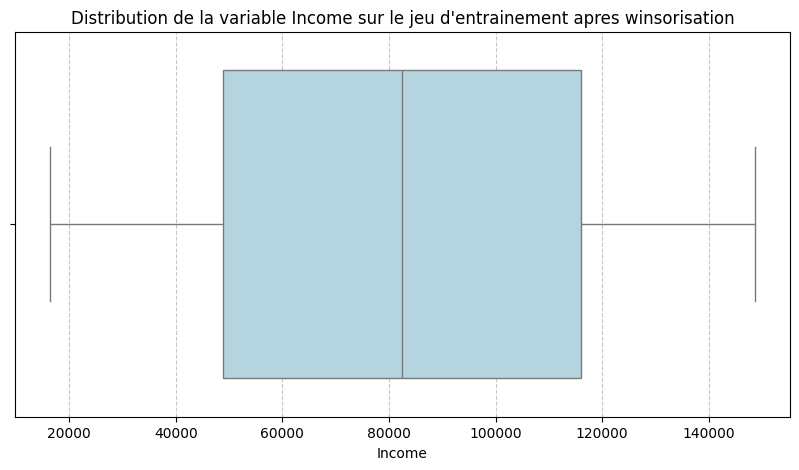

In [10]:
# Vérification visuelle de la distribution après traitement
variable_test = 'Income'

plt.figure(figsize=(10, 5))
sns.boxplot(x=ensembles['train'][variable_test], color='lightblue')
plt.title(f"Distribution de la variable {variable_test} sur le jeu d'entrainement apres winsorisation")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [11]:
# Sauvegarde des partitions nettoyées
dossier_export = 'data_cleaned'
os.makedirs(dossier_export, exist_ok=True)

ensembles['train'].to_csv(os.path.join(dossier_export, 'train.csv'), index=False, sep=';')
ensembles['val'].to_csv(os.path.join(dossier_export, 'val.csv'), index=False, sep=';')
ensembles['test'].to_csv(os.path.join(dossier_export, 'test.csv'), index=False, sep=';')

print(f"Exportation des donnees terminee dans le repertoire : {dossier_export}")

Exportation des donnees terminee dans le repertoire : data_cleaned
